In [97]:
# Password-protected file access (to be used across Jupyter notebooks)

import msoffcrypto # To access password-protected files
import pandas as pd # To read and manipulate data
from io import BytesIO # Temp handling of decrypted files
from getpass import getpass # Get password input w/out encoding

password = getpass("Enter anon file password: ") # Prompt for password
decrypted_file = BytesIO() # Creates temp file in memory

with open(r"C:\Users\karin\Documents\2. Data\Anonymous_Data.xlsx", "rb") as f: # Open the password-protected file
    office_file = msoffcrypto.OfficeFile(f) # Create Officefile object
    office_file.load_key(password=password) # Load password
    office_file.decrypt(decrypted_file) # Decrypt file into memory

df = pd.read_excel(decrypted_file) # Read decrypted file into a DataFrame (DF)
df.shape # Display the shape of the DF (rows and columns)

(2839, 88)

In [98]:
# Rebuild df_binary for attendance feature below

fail_categories = ['Fail Resit', 'Fail Withdraw', 'Repeat without Attendance', 'Repeat with Attendance', 'Complete Repeat'] # Defining categories which count as a fail
df_binary = df[df['Progression Decision'] != 'Trail Progress'].copy() # Create a new DF excluding 'Trail Progress' rows as it is its own edge case
df_binary['initially_failed'] = df_binary['Progression Decision'].isin(fail_categories) # Create new column in new DF: True if student failed and false if they passed

df_binary.shape # Display the shape of the DF (rows and columns)

(2837, 89)

In [99]:
# Attendance Feature: already numeric but accouting for off-site students with null values

df_binary['is_offsite'] = df_binary['Attendance (%)'].isnull() # Create new column which turns true if attendance is null (off-site student)
df_binary['is_offsite'].value_counts() # Count the number of off-site students (True) and on-site students (False)

is_offsite
False    2785
True       52
Name: count, dtype: int64

In [100]:
# Attendance Feature: check if any off-site students are categorised as on-site via admin student status

df_binary['no_attendance_data'] = df_binary['Attendance (%)'].isnull() # Create new column which turns true if attendance is null (off-site student)
df_binary[df_binary['no_attendance_data']]['Student Status'].value_counts() # Count no. students off-site but categorised via admin student status

Student Status
Off-site     41
PR/Repeat    10
Normal        1
Name: count, dtype: int64

In [101]:
# Breakdown of student numbers via three student statuses

df_binary['is_offsite'] = df_binary['Student Status'].str.contains('Off-site', case=False, na=False) # Create new column which turns true if student status contains 'Off-site' (off-site student)
df_binary['is_repeating'] = df_binary['Student Status'].str.contains('PR/Repeat', case=False, na=False) # Create new column which turns true if student status contains 'PR/Repeat' (repeating student)
df_binary['unexplained_null_attendance'] = df_binary['no_attendance_data'] & ~df_binary['is_offsite'] & ~df_binary['is_repeating'] # Create new column which turns true if student has no attendance data but is not off-site or repeating

df_binary[['is_offsite', 'is_repeating', 'unexplained_null_attendance']].sum() # Count students in each category

is_offsite                     42
is_repeating                   92
unexplained_null_attendance     1
dtype: int64

In [102]:
# Dividing repeating students into two categories: those with and without attendance expectation

df_binary['is_repeating'] = df_binary['is_repeating'] # All repeating students for general repeat flag
df_binary['repeating_with_no_attendance_expectation'] = df_binary['is_repeating'] & df_binary['Attendance (%)'].isnull() # Those repeating without attendance expectation
df_binary['repeating_with_attendance'] = df_binary['is_repeating'] & df_binary['Attendance (%)'].notnull() # Those repeating with attendance expectation

df_binary[['repeating_with_no_attendance_expectation', 'repeating_with_attendance']].sum() # Count students in each category

repeating_with_no_attendance_expectation    10
repeating_with_attendance                   82
dtype: int64

In [103]:
# Rebuild list of VLE columns

vle_columns = [col for col in df.columns if 'VLE' in col] # List VLE columns
len(vle_columns) # Display the number of VLE columns

19

In [104]:
# VLE Engagement Score

rag_map = {'RED': 0, 'AMBER': 1, 'GREEN': 2} # Ordinal mapping for RAG values, the higher, the better the engagement score

vle_numeric = df_binary[vle_columns].apply(lambda col: col.str.upper()) # Convert all RAG values to uppercase to avoid errors
vle_numeric = vle_numeric.replace(rag_map).replace('GREY', pd.NA) # Replace RAG values with numeric values and replace GREY with null
vle_numeric = vle_numeric.apply(pd.to_numeric, errors='coerce') # Convert all values to numeric

df_binary['vle_avg_score'] = vle_numeric.mean(axis=1) # Calculate the average VLE score for each student across all weeksand store in a new column
df_binary['vle_red_weeks'] = (vle_numeric == 0).sum(axis=1) # Count the number of RED weeks for each student
df_binary['vle_grey_weeks'] = vle_numeric.isnull().sum(axis=1) # Count the number of GREY weeks for each student
df_binary['has_grey_vle'] = df_binary['vle_grey_weeks'] > 3 # Binary flag check if student has more than 3 GREY weeks (adjusted as fewer likely reflects late registration)

df_binary[['vle_avg_score', 'vle_red_weeks', 'vle_grey_weeks', 'has_grey_vle']].describe() # Print the scores

,vle_avg_score,vle_red_weeks,vle_grey_weeks
count,2746.000000,2837.000000,2837.000000
mean,1.315146,3.348255,1.381036
std,0.499003,4.320137,4.126316
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,1.421053,2.000000,0.000000
75%,1.736842,5.000000,0.000000
max,2.000000,19.000000,19.000000


In [105]:
# Flag for no VLE data students

df_binary['no_vle_data'] = df_binary['vle_avg_score'].isnull() # Pulls 91 students who's overall VLE engagement is null (grey or non-existant)
df_binary['no_vle_data'].sum() # Check for 91 returned

91

In [106]:
# Departments as categorical confirmation

df_binary['Department'].value_counts() # Confirm there are only 3 departments

Department
Department B    1174
Department A    1042
Department C     621
Name: count, dtype: int64

In [107]:
# Admin Status categorical confirmation

df_binary['Admin Status'].value_counts() # Check for clean categories (incl. any typos)

Admin Status
Current Student          2143
Complete & Awarded        535
Withdrawn                 100
Early Exit with Award      44
Dormant Student            10
Suspended Student           4
Transferred Course          1
Name: count, dtype: int64

In [108]:
# Student Status categorical confirmation

df_binary['Student Status'].value_counts() # Check for clean categories (incl. any typos)

Student Status
Normal       2703
PR/Repeat      92
Off-site       42
Name: count, dtype: int64

In [109]:
# Encoding categoricals

categorical_cols = ['Department', 'Student Status', 'Year Group'] # Columns that need to be one-hot encoded - Added Year Group
df_encoded = pd.get_dummies(df_binary, columns=categorical_cols, drop_first=False) # New column created per category as True or False
df_encoded = df_encoded.drop(columns=['Admin Status']) # Drop Admin Status due to data leakage
df_encoded.shape # Check new column count

(2837, 108)

EDITS: added 'Year Group' as this needs to be one-hot encoded too and removed 'Admin Status' due to data leakage

In [110]:
# Run check on columns to confirm

[col for col in df_encoded.columns if 'Admin Status' in col or 'Student Status' in col or 'Department' in col]

['Department_Department A',
 'Department_Department B',
 'Department_Department C',
 'Student Status_Normal',
 'Student Status_Off-site',
 'Student Status_PR/Repeat']

In [111]:
# Final check on rows and columns

df_encoded.shape # Should remain as 2837, 110 (no rows lost or duplicated during the encoding)

(2837, 108)

In [112]:
# Dropping columns used for manual checks

df_encoded = df_encoded.drop(columns=['Notes', 'check'])
df_encoded.shape # check the two columns are dropped

(2837, 106)

In [113]:
# Final check on nulls (or greys)

null_check = df_encoded.isnull().sum() # Count any nulls per column
null_check[null_check > 0] # Show only the columns that have nulls

Attendance (%)                       52
Week 1 & 2 Attendance %             129
Week 2 & 3 Attendance %             106
Week 3 & 4 Attendance %              90
Week 4 & 5 Attendance %              86
Week 5 & 6 Attendance %              86
Week 6 & 7 Attendance %              84
Week 7 & 8 Attendance %              82
Week 8 & 9 Attendance %              81
Week 9 & 10 Attendance %             81
Week 11 & 12 Attendance %           110
Week 11 & 12 Attendance RAG          21
Week 11 & 12 VLE Engagement RAG      21
Week 11 & 12 COMBINED RAG            21
Week 12 & 13 Attendance %           110
Week 12 & 13 Attendance RAG          21
Week 12 & 13 VLE Engagement RAG      21
Week 12 & 13 COMBINED RAG            21
Week 13 & 14 Attendance %           110
Week 13 & 14 Attendance RAG          21
Week 13 & 14 VLE Engagement RAG      21
Week 13 & 14 COMBINED RAG            21
Week 14 & 15 Attendance %           110
Week 14 & 15 Attendance RAG          21
Week 14 & 15 VLE Engagement RAG      21


All code above copied over from '3_Feature_Engineering' notebook ready for Logistic Regression apart from 1 edit (see EDIT md above)

In [114]:
# X/y split

leakage_and_id_cols = ['Academic Year', 'Student_ID', 'Progression Decision', 'Resit?', 'Progression Decision (Resit)', 'is_repeating', 'repeating_with_attendance', 'repeating_with_no_attendance_expectation'] # Columns which will be excluded as information is not relevant to prediction
raw_rag_cols = [col for col in df_encoded.columns if 'RAG' in col and 'has_grey' not in col] # Gets all raw weekly RAG text columns as there is summary features
weekly_pct_cols = [col for col in df_encoded.columns if '&' in col and 'Attendance %' in col] # Gets all raw weekly attendance percentage columns as there is overall attendance percentage

cols_to_drop = leakage_and_id_cols + raw_rag_cols + weekly_pct_cols # Get all columns into one place to remove
X = df_encoded.drop(columns=cols_to_drop + ['initially_failed']) # Create new table but remove said columns as well as the true outcome (as that is the target)
y = df_encoded['initially_failed'] # Single target column

X.shape, y.shape # Print shapes

((2837, 21), (2837,))

Added 'is_repeating', 'repeating_with_attendance' and 'repeating_with_no_attendance_expectation' to exclusion list as its duplicating data (Student Status_PR/Repeat sufficient)

In [115]:
# Check to ensure all features exist
X.columns.tolist()

['Attendance (%)',
 'is_offsite',
 'no_attendance_data',
 'unexplained_null_attendance',
 'vle_avg_score',
 'vle_red_weeks',
 'vle_grey_weeks',
 'has_grey_vle',
 'no_vle_data',
 'Department_Department A',
 'Department_Department B',
 'Department_Department C',
 'Student Status_Normal',
 'Student Status_Off-site',
 'Student Status_PR/Repeat',
 'Year Group_Fifth Year',
 'Year Group_First Year',
 'Year Group_Foundation Year',
 'Year Group_Fourth Year',
 'Year Group_Second Year',
 'Year Group_Third Year']

Initial step is to take everything from 'df_encoded' and remove everything that's not necessary or appropriate for the model. Academic Year and Student_ID were removed as non-predictive (and ID will not tell the model about the risks and the year is the same across the board). Progression Decision was removed as we maintained relevant data within 'initially_failed'. Progression Decision (Resit), and Resit? were both removed as they are outcomes that occur after the target itself so including them would let the model see the answer rather than predicting it (data leakage).

Other columns removed include the remaining weekly RAG ratings and the split weekly attendance percentages as these are already captured by the summarised versions which were built in feature engineering (vle_avg_score and the overall Attendance % column). If both were kept it would add redundancy and noise but no real signal.

This leaves the final feature matrix. The remianing features defined in X (the table) and the target in y.

In [116]:
# Train & Test Split

from sklearn.model_selection import train_test_split # Import the split function

X_train, X_test, y_train, y_test = train_test_split (
    X, y,
    test_size=0.2,    # 20% of the data is held back for testing while 80% is left given to training
    stratify=y,       # Keep the same fail/pass ratio across the two sets
    random_state=22   # Fixes the random split so its reproducible
)
X_train.shape, X_test.shape # Confirm split sizes

((2269, 21), (568, 21))

In [117]:
# Check that stratification worked properly

y_train.mean(), y_test.mean()

(0.374173644777435, 0.375)

The students in this dataset are required to be split into two groups: one group the model will learn from (training data) and the other it never sees (testing data), so we can measure how well the model predicts on data it hasn't encountered.

A key consideration here is that the classes are impabalanced, with more passes than fails (as seen in the EDA notebook). A random split could cause too many or too few fails land in one group by chance. To manage this, stratisfied splitting was used, which forces both groups to keep the same fail/pass ratio as the full dataset, for a fairer comparison. An 80/20 split was used (80% for training, 20% for testing), with a fixed random seed (random_state=22) so the split is reproducible.

In [118]:
# Check for student loss if null removed

rows_with_any_null = X[['Attendance (%)', 'vle_avg_score']].isnull().any(axis=1).sum()
rows_with_any_null

103

As Logistic Regression is unable to handle nulls a check was done to see how many students would be lost if rows with missing attendance or VLE data were dropped entirely. This counts any student missing at least one of the two values (not double counting the students who have both missing), to see the real scale before deciding how to handle it. The result was 103.

In [119]:
# Student Status counts of students with null

excluded_mask = X[['Attendance (%)', 'vle_avg_score']].isnull().any(axis=1) 

X_excluded_check = df_encoded[excluded_mask] # Pull all rows for the 103 students
X_excluded_check[['Student Status_Off-site', 'Student Status_PR/Repeat', 'Student Status_Normal']].sum() # Count how many students fall into each category

Student Status_Off-site     42
Student Status_PR/Repeat    60
Student Status_Normal        1
dtype: int64

The output shows that 42 were off-site, 60 were repeating (likely, without attendance, or partially repeating and so had no VLE for the term they did not need to repeat), and 1 normal (an anomaly). With 102 out of the 103 falling into the off-site or repeating categories, attendance and/or VLE engagement are not meaningful signals for the vast majority of this group in the first place - modelling them on these features risks a mismatch between the signal and the student's actual situation, rather then a genuine predictive gap. The single normal status student is treated as an unexplained edge case, consistent with earlier findings in this dataset.

In [120]:
# Implement null handing (exclude from data)

X_excluded = X[excluded_mask].copy() # Pull 103 students features into a seperate table
y_excluded = y[excluded_mask].copy() # Pull 103 outcomes for the students

X_modelling = X[~excluded_mask].copy() # Everyone else BUT the 103 students
y_modelling = y[~excluded_mask].copy() # Same as above for outcomes

X_modelling.shape, X_excluded.shape

((2734, 21), (103, 21))

Split of the table into two bits: one which removes the 103 students meaning it is the students the model will actually learn and be tested on (X_modelling & y_modelling) and the 103 students we are setting aside to discuss seperately (X_excluded & y_excluded).

In [121]:
# New Train & Test Split post exclusion - same steps as before just change of data

X_train, X_test, y_train, y_test = train_test_split(
    X_modelling, y_modelling,
    test_size=0.2,
    stratify=y_modelling,
    random_state=22
)
X_train.shape, X_test.shape

((2187, 21), (547, 21))

In [122]:
# print(X.columns.tolist()) # Quick check before starting the day to ensure year groups one-hot encoded from yesterday

In [123]:
# Fiting the model on the training data

from sklearn.linear_model import LogisticRegression # Import the Logistic Regression Model

logreg = LogisticRegression(max_iter=1000, random_state=22) # Creation of model with max_iter raised incase more steps needed to converge
logreg.fit(X_train, y_train) # Train the model on the training data above

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,22
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [124]:
# Check for fault as ValueError: could not convert string to float: 'Third Year'

# X_train.dtypes[X_train.dtypes == 'object'] # List any columns still stored as text

In [125]:
# Check for values in Year Group column

# df_encoded['Year Group'].unique()

In [126]:
# Ordinal Map - attempted but better solution was one-hot encoding, done and noted above.

# year_map ={'Foundation Year': 0, 'First Year': 1, 'Second Year': 2, 'Third Year': 3, 'Fourth Year': 4, 'Fifth Year': 5} # Convert text to int
# df_encoded['Year Group'] = df_encoded['Year Group'].map(year_map)

# df_encoded['Year Group'].unique() # Expected output is int rather than text
# df_encoded['Year Group'].isnull().sum() # Expected output is 0

The three code blocks above were used to find fault as one column contained text rather then int.

In [127]:
# Predict using trained log reg model

y_pred = logreg.predict(X_test) # Predicted class labels: 0 = pass, 1 = fail

In [ ]:
# Evaluating performance

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score # Import metrics to evaluate the model

print(classification_report(y_test, y_pred)) # Print the precision, recall, f1-score and support for each class

y_fail_proba = logreg.predict_proba(X_test)[:,1] # Calculate AUC-ROC score using predicted probabilities
print("AUC-ROC:", roc_auc_score(y_test, y_fail_proba))

              precision    recall  f1-score   support

       False       0.74      0.87      0.80       344
        True       0.68      0.47      0.56       203

    accuracy                           0.72       547
   macro avg       0.71      0.67      0.68       547
weighted avg       0.72      0.72      0.71       547

AUC-ROC: 0.7739145377477373


For the baseline model,the recall on True (fail) is 0.47 meaning the model only catches less than half of the students who actually fail: more than half of the at-risk students slip through undetected. The recall on False (pass) is much better, successfully identifying 87% students who pass. The precision on True is 0.68 which means that when the model does predict a fail, it is right 68% of the time which is quite positive. The AUC-ROC is 0.77 which is a fair overall discrimination between classes indicating the model has learned real signal. Overall, it's a good baseline pattern - model shows it is skewed toward the majority class (pass) which is why the recall on fail is weak supporting the decision to apply SMOTE.

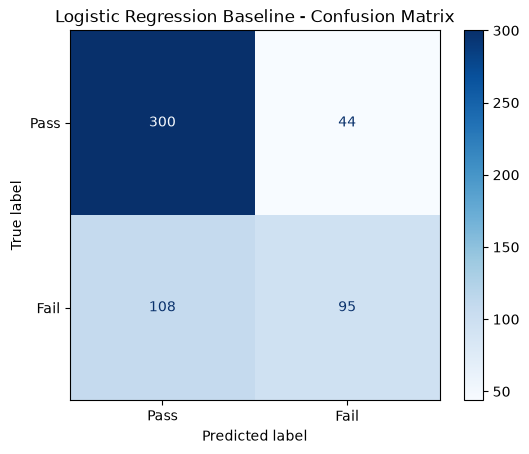

In [129]:
# Confusion Matrix to visualise

# For visualising the CM
import matplotlib.pyplot as plt 
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred) # Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pass", "Fail"]) # Wrap counts for plotting w labels
disp.plot(cmap="Blues") # Render Matrix
plt.title("Logistic Regression Baseline - Confusion Matrix") 
plt.show()

The confusion matrix above confirms the classification report: of the 203 students who actually failed, 108 were missed by the model and predicted as Pass. That means only 95 were correctly identified matching the 0.47 recall on the Fail class. False positives are quite low at 44 meaning that the model is cautious about predicting a fail rather than over-flagging a student. 

In [130]:
# Coefficient inspection - what are the drivers

coefficients = pd.DataFrame({
    "feature": X_train.columns, 
    "coefficient": logreg.coef_[0]
})

coefficients["abs_coefficient"] = coefficients["coefficient"].abs() # The extent of the influence
coefficients = coefficients.sort_values("abs_coefficient", ascending=False) # Biggest influence first

print(coefficients.head(15))

                       feature  coefficient  abs_coefficient
14    Student Status_PR/Repeat     1.181602         1.181602
12       Student Status_Normal    -1.169977         1.169977
20       Year Group_Third Year    -0.522782         0.522782
4                vle_avg_score    -0.424884         0.424884
17  Year Group_Foundation Year     0.403392         0.403392
11     Department_Department C     0.257751         0.257751
10     Department_Department B    -0.153728         0.153728
7                 has_grey_vle     0.111295         0.111295
16       Year Group_First Year     0.099402         0.099402
18      Year Group_Fourth Year    -0.094678         0.094678
9      Department_Department A    -0.092398         0.092398
19      Year Group_Second Year     0.091960         0.091960
5                vle_red_weeks     0.076204         0.076204
15       Year Group_Fifth Year     0.034332         0.034332
0               Attendance (%)    -0.029782         0.029782


Identified data leakage: Admin Status is usually set at the beginning of the year however for students who are marked as Complete & Awarded, Withdrawn, or Early Exit with Award it will reflect their most recent status. This risks encoding the outcome being predicted, for example, a student classed as Complete & Awarded must have passed. Admin status will not be removed from the feature set to avoid this from happening.

Key things to note for the drivers above are that currently, Student Status_PR/Reapeat is the strongest signal with a 1.18 coefficient. The vle_avg_score has a coefficient of -0.42 and is the top continous engagement predictor, showing that higher VLE engagement lowers the risk of failing. Quite surprisingly, Attendance % is faily weak here at -0.03 despite showing a stronger EDA correlation (-0.36) - though this is not a problem, instead it may be that once VLE engagement and repeating statuses are accounted for, attendance's lone contribution shrinks as it correlates with the other features.

In [135]:
# SMOTE application

from imblearn.over_sampling import SMOTE # Importing SMOTE for oversampling minority class

smote = SMOTE(random_state=22)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train) # Resamples the training data only leaving test untouched

y_train_smote.value_counts() 

initially_failed
False    1377
True     1377
Name: count, dtype: int64

In [136]:
# Logistic Regression refit on SMOTE-balanced training data

logreg_smote = LogisticRegression(max_iter=1000, random_state=22)
logreg_smote.fit(X_train_smote, y_train_smote) # Train on the balanced data

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,22
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [137]:
# Evaluate Performance (with SMOTE)

y_pred_smote = logreg_smote.predict(X_test) # Predicts on the test set using the SMOTE-trained model

print(classification_report(y_test, y_pred_smote)) # Evaluate performance

y_fail_proba_smote = logreg_smote.predict_proba(X_test)[:1]
print("AUC-ROC:", roc_auc_score(y_test, y_fail_proba_smote))


              precision    recall  f1-score   support

       False       0.77      0.81      0.79       344
        True       0.64      0.59      0.61       203

    accuracy                           0.72       547
   macro avg       0.70      0.70      0.70       547
weighted avg       0.72      0.72      0.72       547



ValueError: Found input variables with inconsistent numbers of samples: [547, 1]